# 02 Exploratory Data Analysis

This notebook explores the cleaned car auction dataset to understand distributions, relationships between features, and key patterns before building predictive models. The goal is to develop intuition about what drives used car prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Overview

We load the raw dataset (pre-encoding) for visual exploration, since the cleaned/encoded version has ~920 one-hot columns that aren't useful for plotting.

In [2]:
raw_df = pd.read_csv('data/raw/car_prices.csv')
print(f"Shape: {raw_df.shape}")
print(f"\nColumns: {list(raw_df.columns)}")
raw_df.head()

Shape: (558811, 16)

Columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
raw_df.describe()

,year,condition,odometer,mmr,sellingprice
count,558811.000000,547017.000000,558717.000000,558811.000000,558811.000000
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000


In [4]:
print("Null percentages:")
print((raw_df.isnull().mean() * 100).sort_values(ascending=False).round(2))

Null percentages:
transmission    11.70
body             2.36
condition        2.11
trim             1.91
model            1.86
make             1.84
color            0.13
interior         0.13
odometer         0.02
year             0.00
vin              0.00
state            0.00
seller           0.00
mmr              0.00
sellingprice     0.00
saledate         0.00
dtype: float64


For EDA purposes, we drop rows with null values in key columns and filter out obvious data errors (odometer = 999,999).

In [5]:
df = raw_df.dropna(subset=['make', 'model', 'body', 'odometer', 'condition', 'sellingprice']).copy()
df = df[df['odometer'] < 500000]
df = df[df['sellingprice'] > 0]
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)
print(f"Working dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Working dataset: 534,218 rows x 16 columns


/var/folders/25/myn29lpd1kgc8cf9vjv6822h0000gn/T/ipykernel_97960/3382979826.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


## 2. Price Distribution

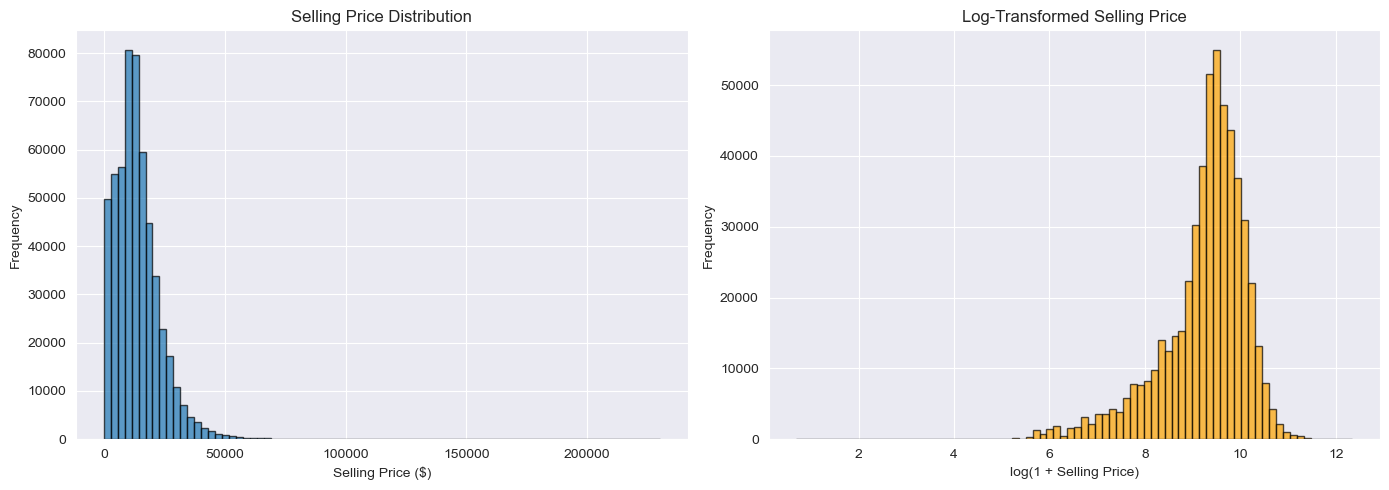

Median price: $12,400
Mean price:   $13,874
Std dev:      $9,694


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sellingprice'], bins=80, edgecolor='black', alpha=0.7)
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Selling Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['sellingprice']), bins=80, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log-Transformed Selling Price')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Median price: ${df['sellingprice'].median():,.0f}")
print(f"Mean price:   ${df['sellingprice'].mean():,.0f}")
print(f"Std dev:      ${df['sellingprice'].std():,.0f}")

The price distribution is right-skewed -- most cars sell under $25k, with a long tail of luxury/specialty vehicles extending past $100k.

## 3. Feature Relationships

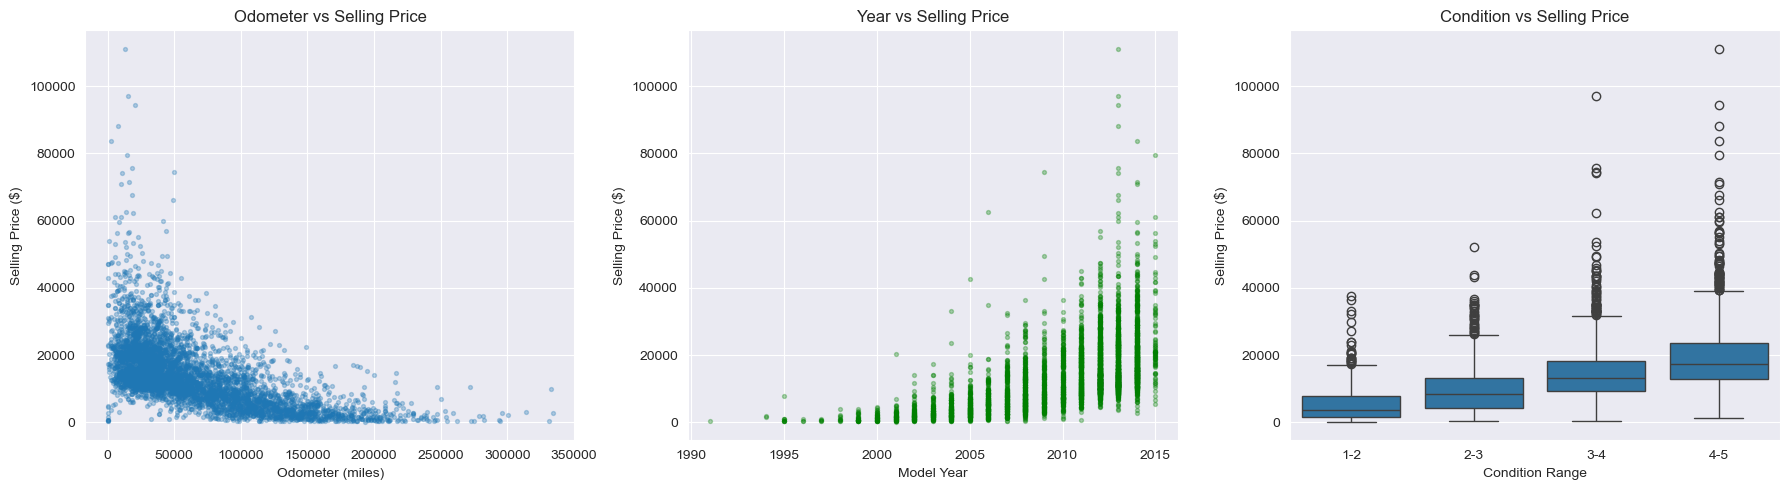

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample = df.sample(5000, random_state=42)

axes[0].scatter(sample['odometer'], sample['sellingprice'], alpha=0.3, s=8)
axes[0].set_title('Odometer vs Selling Price')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Selling Price ($)')

axes[1].scatter(sample['year'], sample['sellingprice'], alpha=0.3, s=8, color='green')
axes[1].set_title('Year vs Selling Price')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Selling Price ($)')

sns.boxplot(x=pd.cut(sample['condition'], bins=[0, 2, 3, 4, 5], labels=['1-2', '2-3', '3-4', '4-5']),
            y=sample['sellingprice'], ax=axes[2])
axes[2].set_title('Condition vs Selling Price')
axes[2].set_xlabel('Condition Range')
axes[2].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()

**Key observations:**
- Higher mileage strongly correlates with lower price.
- Newer model years command higher prices, as expected.
- Better condition scores correspond to higher selling prices, though the spread within each range is wide.

## 4. Correlation Heatmap

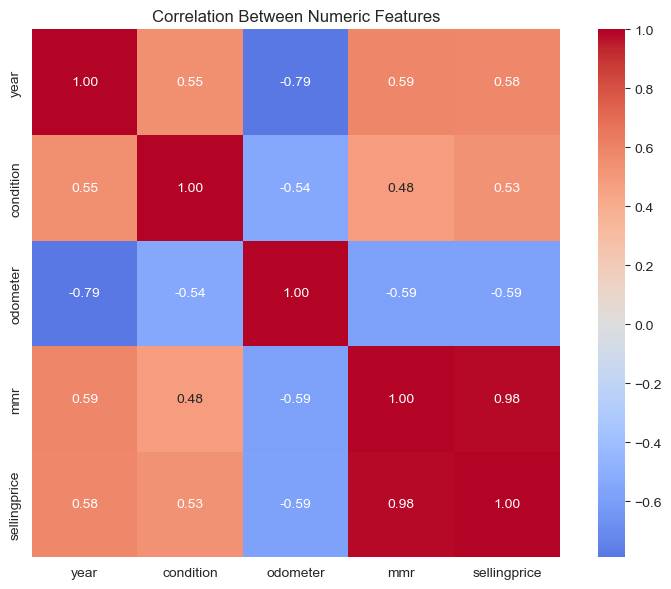

In [8]:
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

`mmr` (Manheim Market Report value) and `sellingprice` are very highly correlated -- this makes sense since MMR is an independent market value estimate for each vehicle. `year` is positively correlated with price, while `odometer` is negatively correlated.

## 5. Geographic Analysis

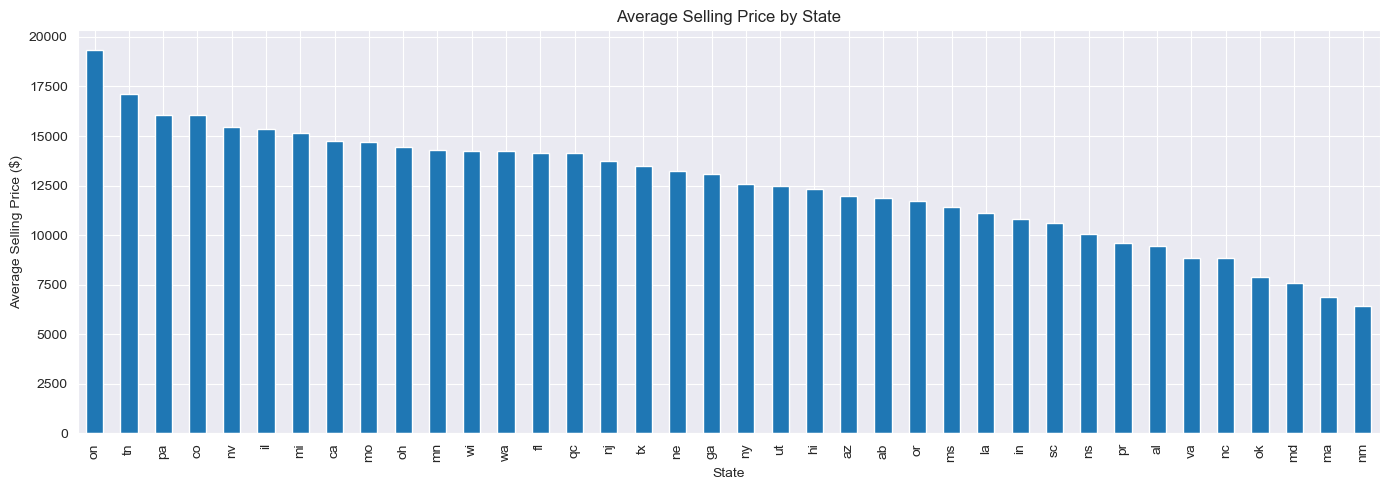

In [9]:
state_avg = df.groupby('state')['sellingprice'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
state_avg.plot(kind='bar')
plt.title('Average Selling Price by State')
plt.xlabel('State')
plt.ylabel('Average Selling Price ($)')
plt.tight_layout()
plt.show()

## 6. Temporal Trends

/var/folders/25/myn29lpd1kgc8cf9vjv6822h0000gn/T/ipykernel_97960/3208409838.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_avg = df_with_dates.groupby(df_with_dates['saledate'].dt.to_period('M'))['sellingprice'].mean()


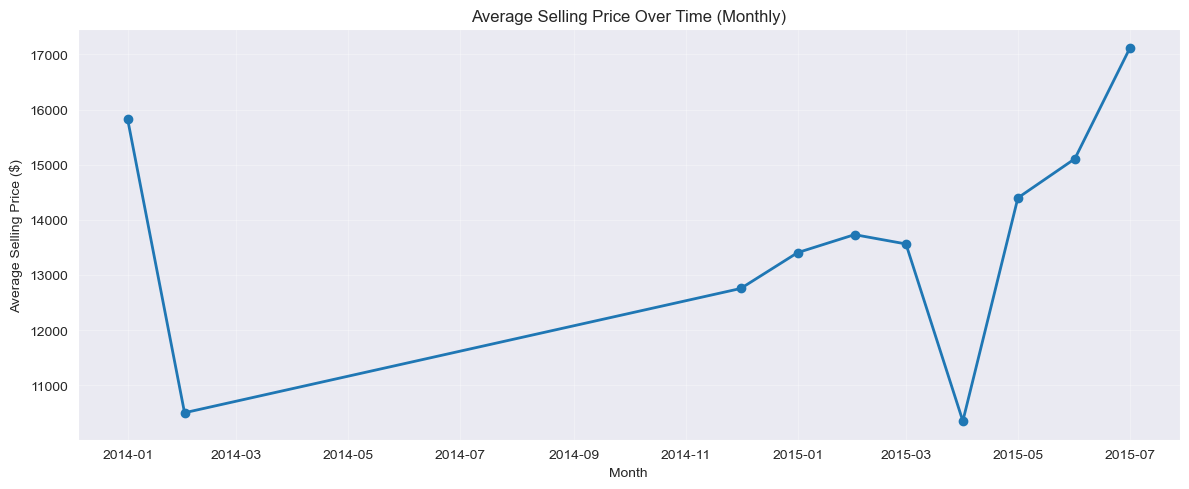

In [10]:
df_with_dates = df.dropna(subset=['saledate'])
monthly_avg = df_with_dates.groupby(df_with_dates['saledate'].dt.to_period('M'))['sellingprice'].mean()
monthly_avg.index = monthly_avg.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
plt.title('Average Selling Price Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Average Selling Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Body Type and Make Analysis

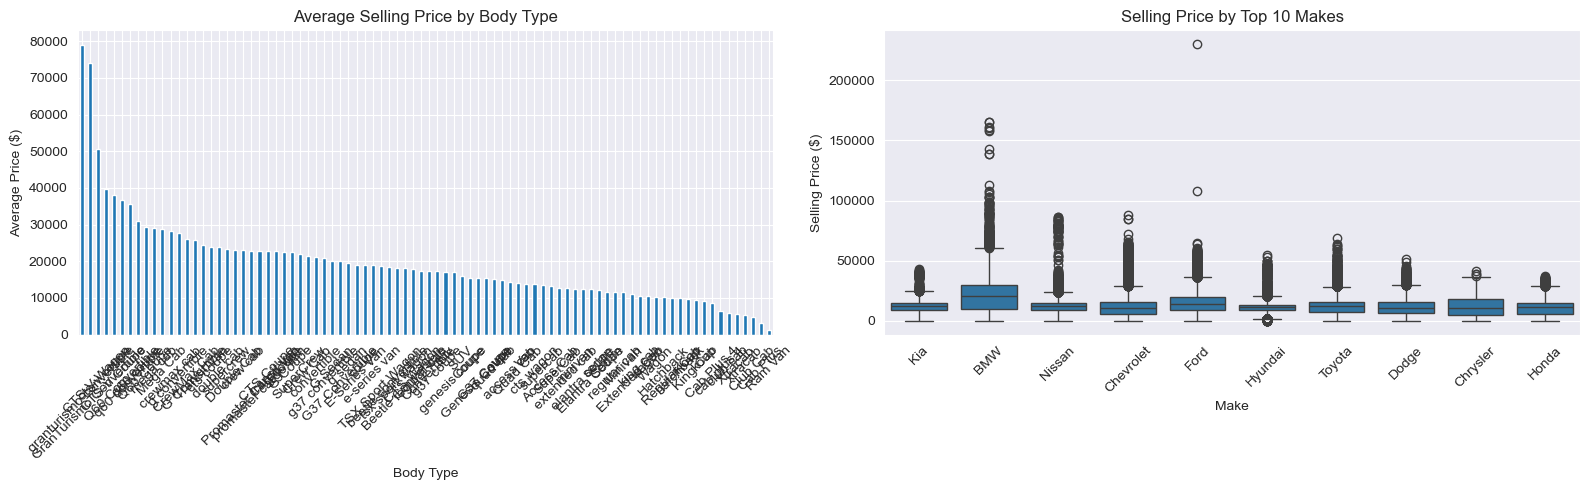

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

body_avg = df.groupby('body')['sellingprice'].mean().sort_values(ascending=False)
body_avg.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Selling Price by Body Type')
axes[0].set_xlabel('Body Type')
axes[0].set_ylabel('Average Price ($)')
axes[0].tick_params(axis='x', rotation=45)

top_10_makes = df['make'].value_counts().head(10).index
sns.boxplot(x='make', y='sellingprice', data=df[df['make'].isin(top_10_makes)], ax=axes[1])
axes[1].set_title('Selling Price by Top 10 Makes')
axes[1].set_xlabel('Make')
axes[1].set_ylabel('Selling Price ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Price is right-skewed** -- the majority of vehicles sell between $5k-$25k, with a long tail of luxury vehicles.
2. **MMR is the strongest single predictor** of selling price (correlation ~0.98), which makes sense since it represents an independent market valuation.
3. **Odometer and year** have strong but opposing relationships with price -- higher mileage lowers value, newer years raise it.
4. **Condition** matters but has wide variance within each range, suggesting other factors (make, model, features) heavily influence price.
5. **Geographic differences** exist across states, likely reflecting regional demand and inventory mix.

These patterns suggest that a model using the full feature set (make, model, body type, state, etc.) should substantially outperform one using only the core numeric features.